In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# DINOv2 Classifier


This notebook is the LeViT Classifer notebook modified to work with DINOv2. The structure is the same.

*AI Use Disclaimer*

- Debugging
- Plotting 


## 1) Import methods

In [3]:
# Imports


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import random
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize


from transformers import AutoModel
from torchvision import transforms
import torchvision.transforms as T
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc 


plt.style.use('default')
sns.set_palette("husl")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, timm: {timm.__version__}, Device: {device}")



PyTorch: 2.10.0+cu128, timm: 1.0.25, Device: cuda


## 2) Load dataset

In [4]:
DATA_DIR = Path('/kaggle/input/datasets/archiesrikumar/bec-dataset/data')
DATA_FILES_DIR = DATA_DIR / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' /'data_roster.csv'

print(DATA_FILES_DIR.exists())  
print(LABELS_FILE.exists())    
labels_df = pd.read_csv(LABELS_FILE, index_col=0)

def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    class_dirs = sorted(
        [d for d in data_dir.glob('class-*') if d.is_dir()],
        key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else 0
    )
    all_files = []
    for cd in class_dirs:
        all_files.extend(sorted(cd.glob('*.npy')))
    
    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)
    if max_samples:
        all_files = all_files[:max_samples]

    images, labels_list, positions_list = [], [], []
    for fp in tqdm(all_files, desc="Loading"):
        try:
            d = np.load(fp, allow_pickle=True).item()
            img = d['masked_data'].reshape(132, 164, 1)
            rel = '/data/' + '/'.join(fp.parts[-3:])
            if rel in labels_df.index:
                row = labels_df.loc[rel]
                label = int(row['label_v3'])
                pos_str = row['excitation_position']
                pos = []
                if not pd.isna(pos_str) and pos_str != '':
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except:
                        pos = []
                images.append(img)
                labels_list.append(label)
                positions_list.append(pos)
        except Exception as e:
            print(f"Error: {fp}: {e}")

    images = np.array(images, dtype=np.float32)
    labels_arr = np.array(labels_list, dtype=np.int32)
    print(f"Loaded {len(images)} images {images.shape}")
    return images, labels_arr, positions_list

images, labels, positions = load_bec_dataset(DATA_FILES_DIR, labels_df, max_samples=None)

True
True


Loading: 100%|██████████| 16478/16478 [02:22<00:00, 115.68it/s]


Loaded 16478 images (16478, 132, 164, 1)


##  3) Filter and split the data

In [5]:
valid = labels < 8
images_f = images[valid]
labels_f = labels[valid].copy()
positions_f = [positions[i] for i in range(len(positions)) if valid[i]]

labels_f[labels_f >= 2] = 2
print(f"Filtered: {len(images_f)}, distribution: {np.bincount(labels_f)}")

X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(
    images_f, labels_f, positions_f,
    test_size=0.2, random_state=42, stratify=labels_f
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train dist: {np.bincount(y_train)}, Test dist: {np.bincount(y_test)}")


Filtered: 5378, distribution: [1130 3212 1036]
Train: 4302, Test: 1076
Train dist: [ 904 2569  829], Test dist: [226 643 207]


## 4) Define dataset, model and training method

In [6]:
class BECDataset(Dataset):
    def __init__(self, images, labels, transform=None, augment=False):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        
        img = np.squeeze(self.images[idx]).astype(np.float32)

        if img.max() > 1.0:
            img = img / 255.0

        img_3ch = np.stack([img, img, img], axis=0) 

        img_tensor = torch.from_numpy(img_3ch)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_tensor = (img_tensor - mean) / std

        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_tensor, label




def create_Dinov2(num_classes, pretrained=True, freeze_backbone=True):
    """
    Creates a DINOv2-based classifier for BEC soliton images.
    
    Args:
        num_classes (int): Number of soliton categories.
        pretrained (bool): Whether to load ImageNet-pretrained weights.
        freeze_backbone (bool): If True, only the classification head trains.
    """
    
    # 1. Load the backbone (Small version: 384-dim output)

    backbone = AutoModel.from_pretrained('facebook/dinov2-small')
    
    # 2. Freeze the backbone parameters
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False
            
    # 3. Define the classification head

    classifier_head = nn.Sequential(
        nn.Linear(384, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    
    # 4. Attach the head to the backbone
    class DINOv2Classifier(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head
            
        def forward(self, x):
            # Extract features (the CLS token / pooler_output)
            features = self.backbone(x).pooler_output
            return self.head(features)

    model = DINOv2Classifier(backbone, classifier_head)
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"Model created on {device}. Backbone frozen: {freeze_backbone}")
    return model


def unfreeze_model(model, backbone_lr=1e-6, head_lr=1e-4): # Lower backbone LR
    for p in model.parameters():
        p.requires_grad = True

    backbone_params = []
    head_params = []

    for name, p in model.named_parameters():
        # Change 'classifier' to 'head' to match our DINOv2 model
        if 'head' in name: 
            head_params.append(p)
        else:
            backbone_params.append(p)

    print(f"Unfrozen: {len(backbone_params)} backbone tensors, {len(head_params)} head tensors")

    return [
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr},
    ]



def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        probs = torch.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def two_phase_train(model, train_loader, val_loader, device,
                    phase1_epochs=50, phase2_epochs=50,
                    phase1_lr=1e-3, phase2_backbone_lr=3e-6, phase2_head_lr=5e-4):
    """
    Back to the 0.8548 settings, only adapter_dim changed.
    """
    # Class weights
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.numpy())
    counts = np.bincount(all_labels)
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(counts)
    criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(weights).to(device),
    label_smoothing=0.1
)

    history = {'phase': [], 'epoch': [], 'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    PATIENCE = 10

    # ---- Phase 1 ----MMMM
    print("Phase 1: Head + adapter only")
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=phase1_lr, weight_decay=1e-4
    )
    sched1 = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase1_epochs, eta_min=phase1_lr * 0.01
    )

    for epoch in range(phase1_epochs):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, val_loader, criterion, device)
        sched1.step()

        history['phase'].append(1)
        history['epoch'].append(epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase2_epochs} | "
                  f"train={ta:.4f} val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    # ---- Phase 2 ----
    print(f"\nPhase 2: Full fine-tuning")
    model.load_state_dict(best_state)
    param_groups = unfreeze_model(model, phase2_backbone_lr, phase2_head_lr)
    opt = optim.AdamW(param_groups, weight_decay=1e-4)
    sched2 = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase2_epochs, eta_min=phase2_backbone_lr * 0.01
    )
    patience_counter = 0

    for epoch in range(phase2_epochs):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, val_loader, criterion, device)
        sched2.step()

        history['phase'].append(2)
        history['epoch'].append(phase1_epochs + epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase2_epochs} | "
                  f"train={ta:.4f} val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
    return history


## 5) Baseline

In [19]:
print("STEP 1: Baseline — DINOv2-Small (Frozen Backbone)")


num_classes = 3 
model = create_Dinov2(num_classes).to(device)
dinov2_transforms = T.Resize((224, 224))


train_ds = BECDataset(X_train, y_train, transform=dinov2_transforms)
test_ds = BECDataset(X_test, y_test, transform=dinov2_transforms)


train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


history = two_phase_train(model, train_loader, test_loader, device)


criterion = nn.CrossEntropyLoss()
_, acc, y_pred, y_true, y_probs = eval_model(model, test_loader, criterion, device)

print(f"\nDINOv2 Baseline test accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, digits=4,
      target_names=['No soliton', 'Single', 'Other']))

torch.save(model.state_dict(), 'dinov2_soliton_baseline.pth')
print("Saved baseline weights")


STEP 1: Baseline — DINOv2-Small (Frozen Backbone)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.8354 val=0.8020 | backbone_lr=9.76e-04
  10/50 | train=0.8645 val=0.8801 | backbone_lr=9.05e-04
  Early stopping at epoch 13

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.9219 val=0.8987 | backbone_lr=2.93e-06
  10/50 | train=0.9491 val=0.9507 | backbone_lr=2.72e-06
  15/50 | train=0.9540 val=0.9266 | backbone_lr=2.39e-06
  20/50 | train=0.9665 val=0.9572 | backbone_lr=1.97e-06
  25/50 | train=0.9793 val=0.9656 | backbone_lr=1.51e-06
  30/50 | train=0.9916 val=0.9647 | backbone_lr=1.06e-06
  35/50 | train=0.9954 val=0.9628 | backbone_lr=6.42e-07
  40/50 | train=0.9981 val=0.9712 | backbone_lr=3.14e-07
  45/50 | train=0.9998 val=0.9703 | backbone_lr=1.03e-07
  Early stopping at epoch 48

Best val accuracy: 0.9721

DINOv2 Baseline test accuracy: 0.9721
              precision    recall  f1-score   support

  No soliton     1.0000    0.9956    0.9978     

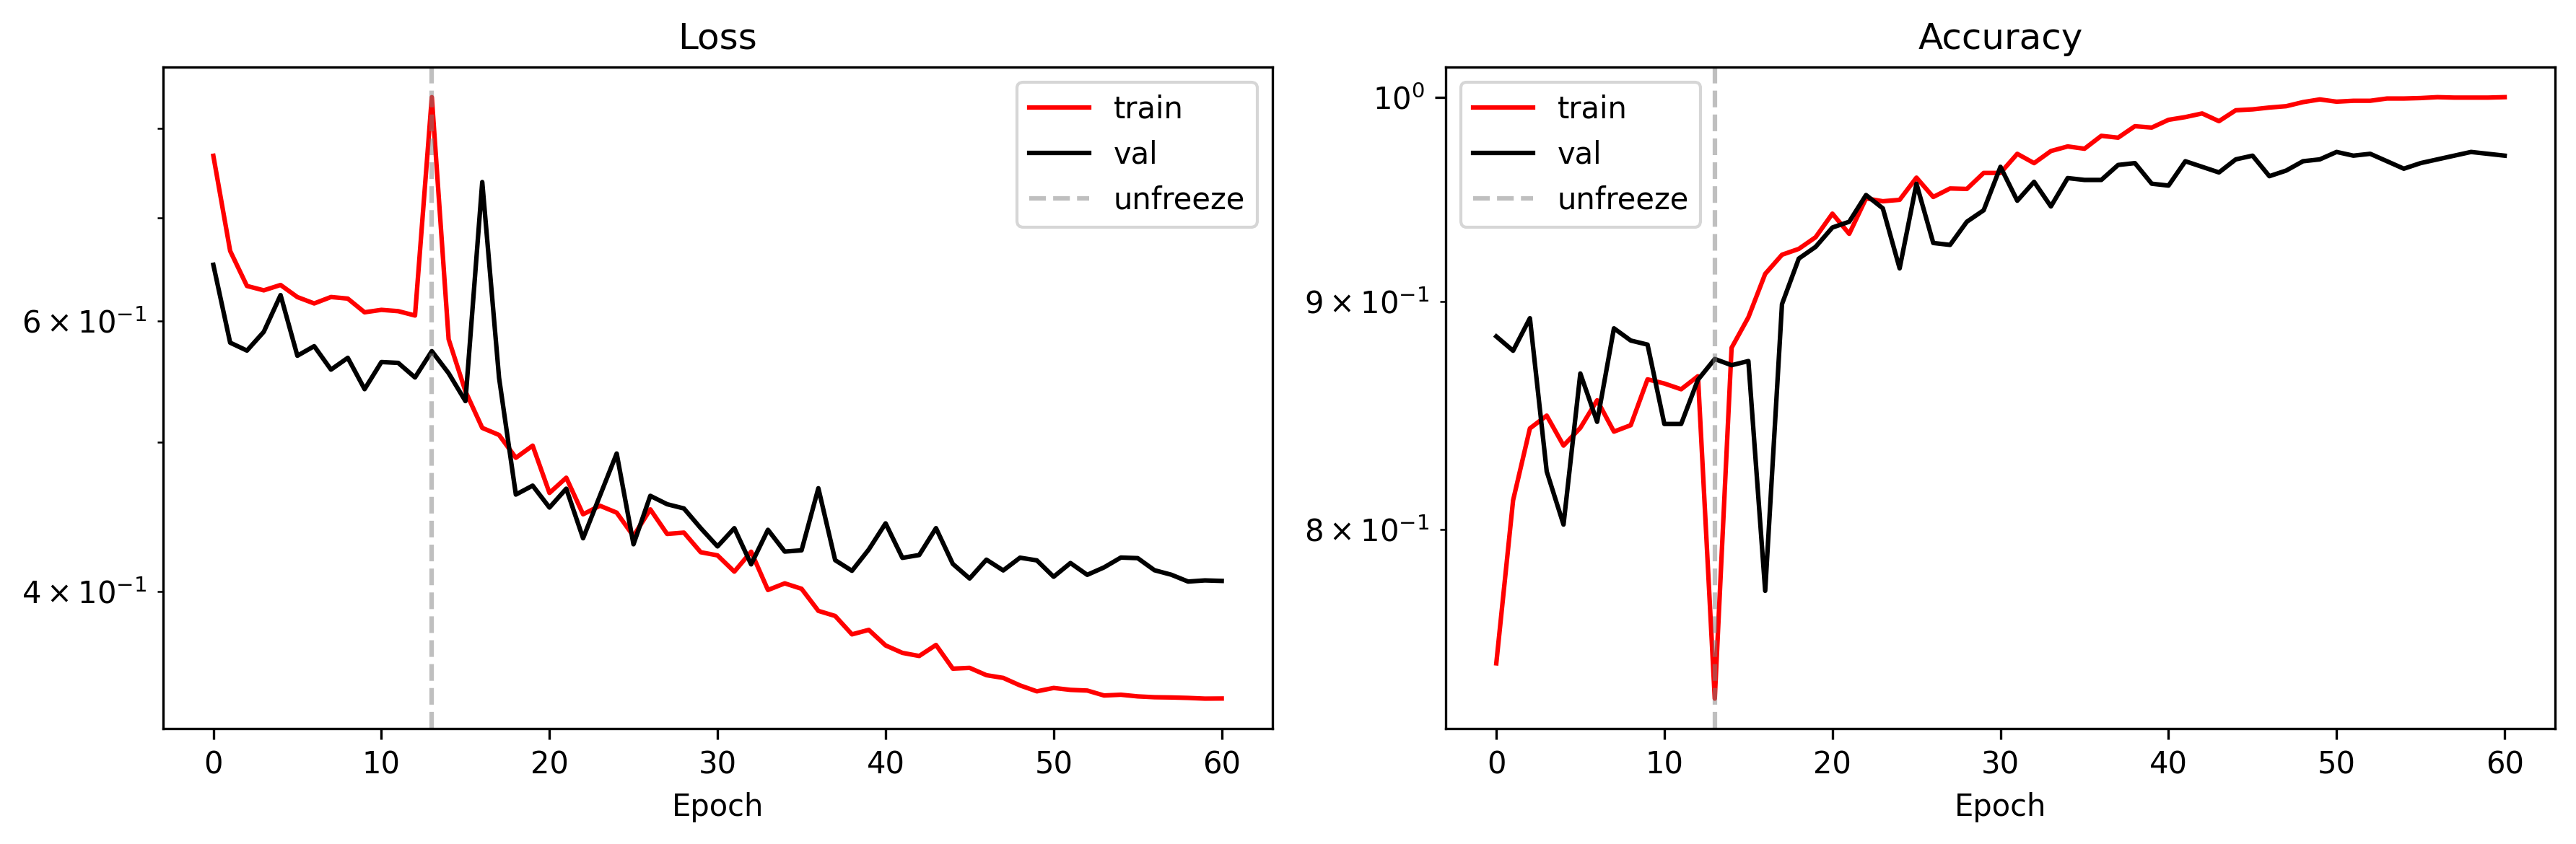

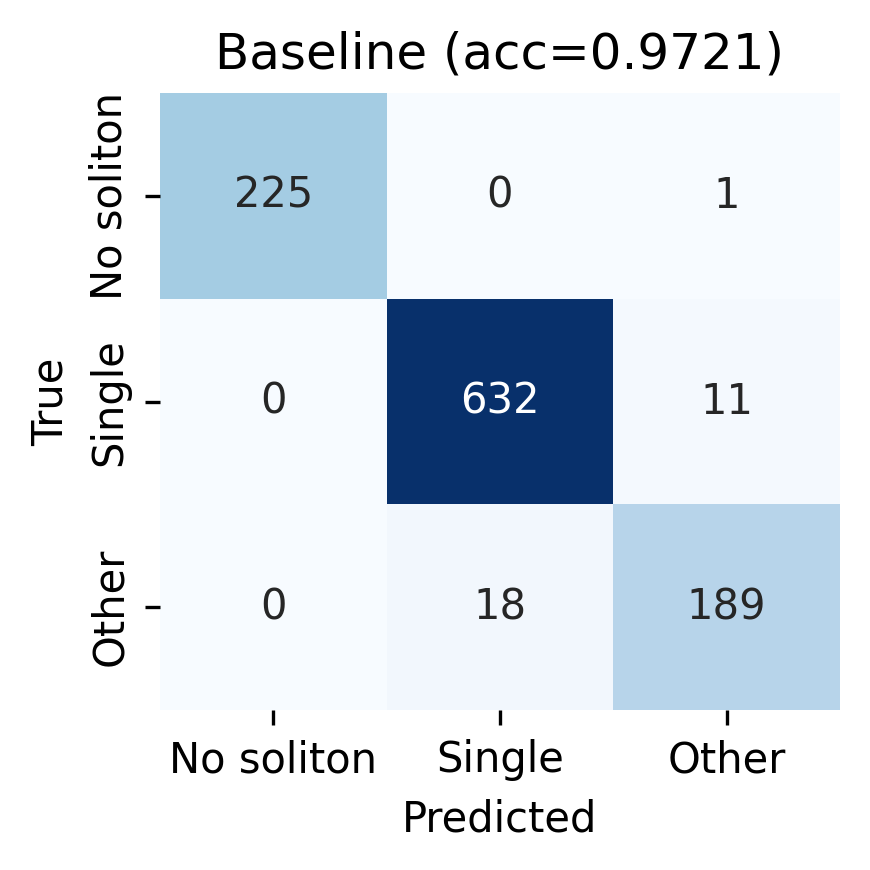

In [23]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
phase1_end = sum(1 for p in history['phase'] if p == 1)
for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    
    ax.set_yscale('log')
    ax.plot(history[f'train_{metric}'], label='train', color='red')
    ax.plot(history[f'val_{metric}'], label='val', color = 'black')
    ax.axvline(x=phase1_end, color='gray', ls='--', alpha=0.5, label='unfreeze')
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig("Loss and accuracy training curves-DINOv2.png")
plt.show()


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(3, 3),dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No soliton', 'Single', 'Other'],
            yticklabels=['No soliton', 'Single', 'Other'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Baseline (acc={acc:.4f})')
plt.tight_layout()
plt.savefig("Baseline confusion matrix-DINOv2.png")
plt.show()



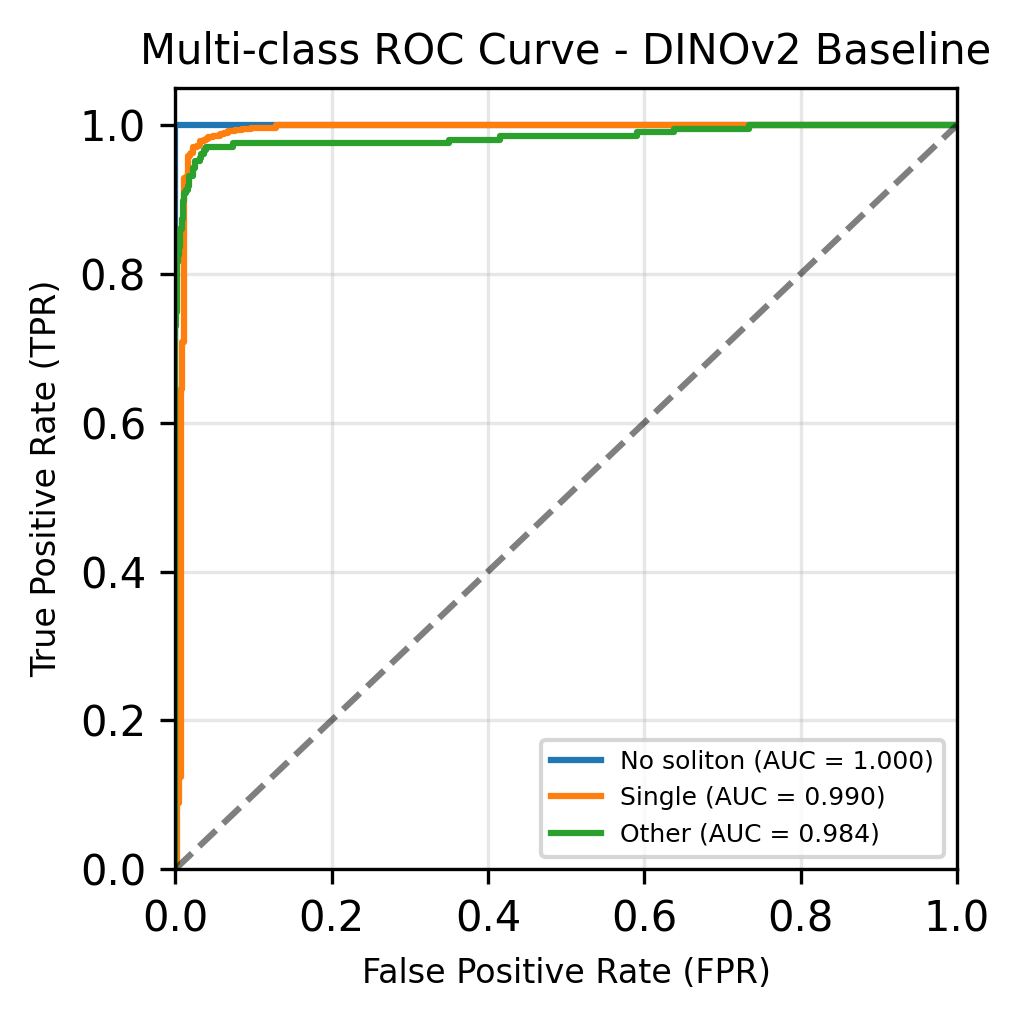

In [33]:
class_names = ['No soliton', 'Single', 'Other']
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc_dict = dict() 
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc_dict[i] = sklearn_auc(fpr[i], tpr[i])


plt.figure(figsize=(3.5, 3.5), dpi=300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=8)
plt.ylabel('True Positive Rate (TPR)', fontsize=8)
plt.title('Multi-class ROC Curve - DINOv2 Baseline', fontsize=10)
plt.legend(loc="lower right", fontsize=6)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Baseline ROC-DINOv2-Test.jpg')
plt.show()


## 6) 5-fold cross-validation

In [10]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_models = []
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n--- Fold {fold}/{N_FOLDS} ---")

    X_f_tr, y_f_tr = X_train[train_idx], y_train[train_idx]
    X_f_va, y_f_va = X_train[val_idx], y_train[val_idx]

    f_tr_loader = DataLoader(
        BECDataset(X_f_tr, y_f_tr, augment=True),
        batch_size=32, shuffle=True, num_workers=2
    )
    f_va_loader = DataLoader(
        BECDataset(X_f_va, y_f_va, augment=False),
        batch_size=32, shuffle=False, num_workers=2
    )

    fold_model = create_Dinov2(
        num_classes=3,
        freeze_backbone=True
    ).to(device)

    fold_history = two_phase_train(
        fold_model, f_tr_loader, f_va_loader, device
    )

    _, fold_acc, fold_preds, fold_labels, fold_probs = eval_model(
        fold_model, f_va_loader, criterion, device
    )

    fold_models.append(fold_model)
    fold_results.append({
        'fold': fold,
        'val_acc': fold_acc,
        'history': fold_history,
    })
    print(f"Fold {fold} val accuracy: {fold_acc:.4f}")

accs = [r['val_acc'] for r in fold_results]
print(f"\n{'='*60}")
print(f"CV Results: {[f'{a:.4f}' for a in accs]}")
print(f"Mean: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Baseline was: {acc:.4f}")
print(f"Difference: {np.mean(accs) - acc:+.4f}")

STEP 2: 5-Fold CV — Dinov2

--- Fold 1/5 ---


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6789 val=0.6179 | backbone_lr=9.76e-04
  10/50 | train=0.6835 val=0.7015 | backbone_lr=9.05e-04
  15/50 | train=0.7033 val=0.7247 | backbone_lr=7.96e-04
  20/50 | train=0.7201 val=0.7282 | backbone_lr=6.58e-04
  25/50 | train=0.7108 val=0.7433 | backbone_lr=5.05e-04
  30/50 | train=0.7289 val=0.7503 | backbone_lr=3.52e-04
  35/50 | train=0.7196 val=0.7584 | backbone_lr=2.14e-04
  40/50 | train=0.7260 val=0.7503 | backbone_lr=1.05e-04
  45/50 | train=0.7370 val=0.7596 | backbone_lr=3.42e-05
  Early stopping at epoch 48

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.8739 val=0.9117 | backbone_lr=2.93e-06
  10/50 | train=0.9297 val=0.9315 | backbone_lr=2.72e-06
  15/50 | train=0.9343 val=0.8978 | backbone_lr=2.39e-06
  20/50 | train=0.9637 val=0.9361 | backbone_lr=1.97e-06
  25/50 | train=0.9782 val=0.9210 | backbone_lr=1.51e-06
  30/50 | train=0.9808 val=

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6844 val=0.7317 | backbone_lr=9.76e-04
  10/50 | train=0.6722 val=0.7131 | backbone_lr=9.05e-04
  15/50 | train=0.6995 val=0.7015 | backbone_lr=7.96e-04
  20/50 | train=0.6864 val=0.7433 | backbone_lr=6.58e-04
  25/50 | train=0.6908 val=0.7631 | backbone_lr=5.05e-04
  30/50 | train=0.7169 val=0.7538 | backbone_lr=3.52e-04
  Early stopping at epoch 35

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.8820 val=0.7619 | backbone_lr=2.93e-06
  10/50 | train=0.9227 val=0.9164 | backbone_lr=2.72e-06
  15/50 | train=0.9430 val=0.9466 | backbone_lr=2.39e-06
  20/50 | train=0.9608 val=0.9141 | backbone_lr=1.97e-06
  Early stopping at epoch 25

Best val accuracy: 0.9466
Fold 2 val accuracy: 0.9466

--- Fold 3/5 ---


...

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6636 val=0.7081 | backbone_lr=9.76e-04
  10/50 | train=0.6923 val=0.7047 | backbone_lr=9.05e-04
  15/50 | train=0.7054 val=0.7488 | backbone_lr=7.96e-04
  20/50 | train=0.7016 val=0.7337 | backbone_lr=6.58e-04
  Early stopping at epoch 25

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.8707 val=0.7721 | backbone_lr=2.93e-06
  10/50 | train=0.9204 val=0.8605 | backbone_lr=2.72e-06
  15/50 | train=0.9370 val=0.9302 | backbone_lr=2.39e-06
  20/50 | train=0.9532 val=0.9291 | backbone_lr=1.97e-06
  25/50 | train=0.9709 val=0.9221 | backbone_lr=1.51e-06
  30/50 | train=0.9834 val=0.9395 | backbone_lr=1.06e-06
  35/50 | train=0.9948 val=0.9372 | backbone_lr=6.42e-07
  40/50 | train=0.9971 val=0.9477 | backbone_lr=3.14e-07
  45/50 | train=0.9985 val=0.9407 | backbone_lr=1.03e-07
  Early stopping at epoch 49

Best val accuracy: 0.9488
Fold 3 val accuracy: 0.9488


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6540 val=0.7128 | backbone_lr=9.76e-04
  10/50 | train=0.6926 val=0.6628 | backbone_lr=9.05e-04
  15/50 | train=0.7156 val=0.7395 | backbone_lr=7.96e-04
  20/50 | train=0.7103 val=0.7163 | backbone_lr=6.58e-04
  Early stopping at epoch 23

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.8983 val=0.9035 | backbone_lr=2.93e-06
  10/50 | train=0.9172 val=0.9291 | backbone_lr=2.72e-06
  15/50 | train=0.9506 val=0.9384 | backbone_lr=2.39e-06
  20/50 | train=0.9590 val=0.9256 | backbone_lr=1.97e-06
  25/50 | train=0.9762 val=0.9360 | backbone_lr=1.51e-06
  30/50 | train=0.9814 val=0.9535 | backbone_lr=1.06e-06
  35/50 | train=0.9936 val=0.9500 | backbone_lr=6.42e-07
  40/50 | train=0.9971 val=0.9547 | backbone_lr=3.14e-07
  45/50 | train=0.9988 val=0.9570 | backbone_lr=1.03e-07
  50/50 | train=0.9988 val=0.9605 | backbone_lr=3.00e-08

Best val accuracy: 0.9628


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model created on cuda. Backbone frozen: True
Phase 1: Head + adapter only
  5/50 | train=0.6702 val=0.7302 | backbone_lr=9.76e-04
  10/50 | train=0.6888 val=0.6802 | backbone_lr=9.05e-04
  15/50 | train=0.7048 val=0.7326 | backbone_lr=7.96e-04
  20/50 | train=0.6973 val=0.7453 | backbone_lr=6.58e-04
  25/50 | train=0.7240 val=0.7535 | backbone_lr=5.05e-04
  30/50 | train=0.7202 val=0.7291 | backbone_lr=3.52e-04
  Early stopping at epoch 33

Phase 2: Full fine-tuning
Unfrozen: 223 backbone tensors, 4 head tensors
  5/50 | train=0.8739 val=0.9047 | backbone_lr=2.93e-06
  10/50 | train=0.9128 val=0.9116 | backbone_lr=2.72e-06
  15/50 | train=0.9367 val=0.9314 | backbone_lr=2.39e-06
  20/50 | train=0.9541 val=0.9384 | backbone_lr=1.97e-06
  25/50 | train=0.9756 val=0.9488 | backbone_lr=1.51e-06
  30/50 | train=0.9893 val=0.9442 | backbone_lr=1.06e-06
  Early stopping at epoch 32

Best val accuracy: 0.9500
Fold 5 val accuracy: 0.9500

CV Results: ['0.9443', '0.9466', '0.9488', '0.9628', '0.

## 7) Compare Ensemble vs Single

Single best model: 0.9721
Ensemble (5 models): 0.9414
Improvement: -0.0307


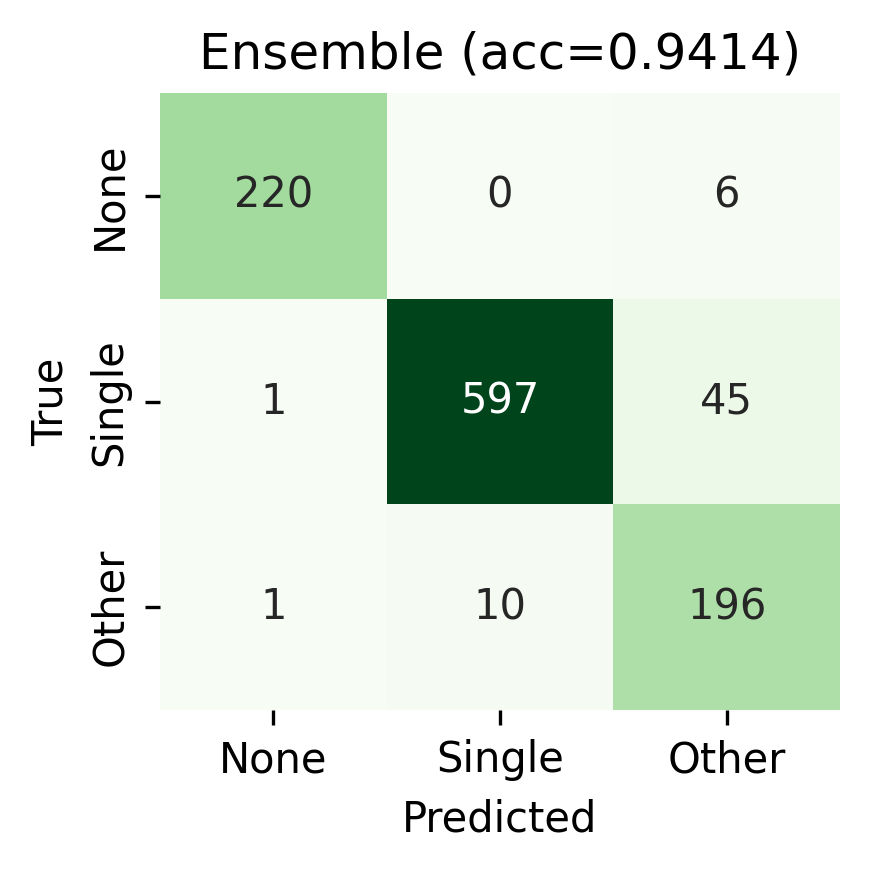


→ Ensemble doesn't help (-3.1%). Use single model.


In [38]:
_, single_acc, single_preds, single_labels, single_probs = eval_model(
    model, test_loader, criterion, device
)

@torch.no_grad()
def ensemble_predict(models, loader, device):
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        batch_probs = []
        for m in models:
            m.eval()
            out = m(imgs)
            batch_probs.append(torch.softmax(out, dim=1).cpu().numpy())
        all_probs.extend(np.mean(batch_probs, axis=0))
        all_labels.extend(labels.numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = all_probs.argmax(axis=1)
    return (all_preds == all_labels).mean(), all_preds, all_labels, all_probs

ensemble_acc, ensemble_preds, ensemble_labels, ensemble_probs = ensemble_predict(
    fold_models, test_loader, device
)

print(f"Single best model: {single_acc:.4f}")
print(f"Ensemble (5 models): {ensemble_acc:.4f}")
print(f"Improvement: {ensemble_acc - single_acc:+.4f}")

plt.figure(figsize=(3, 3), dpi=300)
cm_e = confusion_matrix(ensemble_labels, ensemble_preds)
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Greens',cbar=False,
            xticklabels=['None', 'Single', 'Other'],
            yticklabels=['None', 'Single', 'Other'])
plt.title(f'Ensemble (acc={ensemble_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix_ensemble.png')
plt.show() 


improvement = ensemble_acc - single_acc
if improvement > 0.02:
    print(f"\n→ Ensemble gives {improvement:.1%} improvement. USE ENSEMBLE.")
    use_ensemble = True
elif improvement > 0:
    print(f"\n→ Small improvement ({improvement:.1%}). Ensemble recommended.")
    use_ensemble = True
else:
    print(f"\n→ Ensemble doesn't help ({improvement:+.1%}). Use single model.")
    use_ensemble = False

## 9) Ensemble ROC curve

<Figure size 900x900 with 0 Axes>

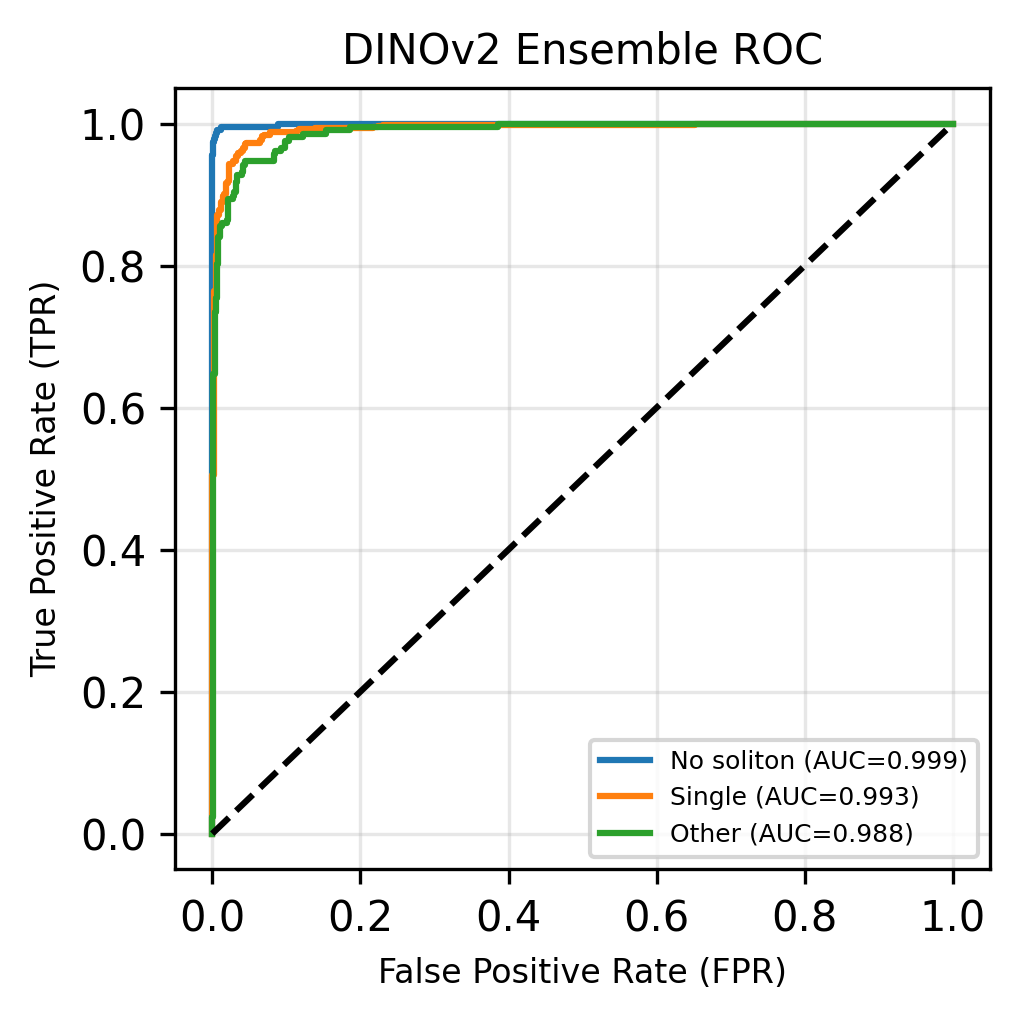

In [40]:
final_probs = ensemble_probs
final_preds = ensemble_preds
final_labels = ensemble_labels
method = "Ensemble"

y_true_bin = label_binarize(final_labels, classes=[0, 1, 2])

plt.figure(figsize=(3, 3), dpi=300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Custom colors

plt.figure(figsize=(3.5, 3.5), dpi=300)
for i, (name, color) in enumerate(zip(['No soliton', 'Single', 'Other'], colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], final_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], final_probs[:, i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (FPR)', fontsize=8)
plt.ylabel('True Positive Rate (TPR)', fontsize=8)
plt.title(f'DINOv2 {method} ROC', fontsize=10)
plt.legend(fontsize=6)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/ROC_ensemble.png')
plt.show()

## 10) Final summary

In [41]:
print("FINAL SUMMARY")
print(f"Model:              levit_128 (1ch + adapter)")
print(f"Baseline accuracy:  {single_acc:.4f}")
print(f"CV mean accuracy:   {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Ensemble accuracy:  {ensemble_acc:.4f}")
print(f"Using:              {'Ensemble' if use_ensemble else 'Single'}")
print(f"Uncertain samples:  {n_uncertain}/{n_total}")

FINAL SUMMARY
Model:              levit_128 (1ch + adapter)
Baseline accuracy:  0.9721
CV mean accuracy:   0.9505 ± 0.0065
Ensemble accuracy:  0.9414
Using:              Single
Uncertain samples:  311/1076
